## Exploratory Data Analysis for Climate Trends in Nigeria


Importing dependencies

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Data Loading and Date Parsing

**Loading the data and viewing the top rows of the data** 

In [2]:
df = pd.read_csv("nigeria.csv")
print(df.shape)
print(df.head())
print(df.info())

(4108, 12)
   YEAR  DOY    T2M  T2M_MAX  T2M_MIN  T2M_RANGE  PRECTOTCORR   RH2M  WS2M  \
0  2015    1  25.23    29.25    22.06       7.19          0.0  68.26  1.73   
1  2015    2  26.16    29.41    22.87       6.54          0.0  73.23  1.42   
2  2015    3  25.66    29.02    22.63       6.39          0.0  78.71  1.69   
3  2015    4  24.11    27.27    19.92       7.35          0.0  63.66  2.15   
4  2015    5  23.40    27.28    18.18       9.10          0.0  59.45  1.88   

   WS2M_MAX      PS   QV2M  
0      2.61  100.86  13.36  
1      1.95  100.94  15.37  
2      2.33  101.06  15.98  
3      3.80  101.09  11.65  
4      3.48  101.03  10.40  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4108 entries, 0 to 4107
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YEAR         4108 non-null   int64  
 1   DOY          4108 non-null   int64  
 2   T2M          4108 non-null   float64
 3   T2M_MAX      4108 non-nu

In [3]:
df.tail()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
4103,2026,86,29.05,32.43,26.69,5.74,2.82,76.60,2.35,3.39,100.58,19.10
4104,2026,87,28.72,31.98,27.14,4.84,5.19,79.61,2.55,3.17,100.64,19.49
4105,2026,88,27.72,29.53,26.21,3.32,1.43,82.83,1.10,1.78,100.61,19.22
4106,2026,89,28.42,31.17,26.36,4.81,0.85,77.73,2.30,3.40,100.53,18.73
4107,2026,90,28.40,31.73,26.32,5.41,5.33,78.79,1.76,2.80,100.59,18.94


**adding country column**

In [4]:
df["country"] = "Nigeria"

**Converting YEAR and DOY columns in to datetime column**

In [5]:
df["Date"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

**Extracting Month as a separate column**

In [6]:
df["Month"] = df["Date"].dt.month
df[["YEAR", "DOY", "Date", "Month"]].head()

,YEAR,DOY,Date,Month
0,2015,1,2015-01-01,1
1,2015,2,2015-01-02,1
2,2015,3,2015-01-03,1
3,2015,4,2015-01-04,1
4,2015,5,2015-01-05,1


### 2. Summary Statistics & Missing-Value Report

**Replacing all occurrences of -999 with np.nan**

In [7]:
df.replace(-999, np.nan, inplace=True)

**Extracting and droping duplicated rows**

In [8]:
duplicates = df.duplicated().sum()
print(f"There are {duplicates} duplicate rows")

df = df.drop_duplicates()

There are 0 duplicate rows


**Checking duplicates for columns**

In [9]:
for col in df.columns:
    dup_count = df[col].duplicated().sum()
    print(f"{col}: {dup_count} duplicate values")

YEAR: 4096 duplicate values
DOY: 3742 duplicate values
T2M: 3591 duplicate values
T2M_MAX: 3505 duplicate values
T2M_MIN: 3472 duplicate values
T2M_RANGE: 3456 duplicate values
PRECTOTCORR: 2871 duplicate values
RH2M: 2645 duplicate values
WS2M: 3820 duplicate values
WS2M_MAX: 3758 duplicate values
PS: 4013 duplicate values
QV2M: 3403 duplicate values
country: 4107 duplicate values
Date: 0 duplicate values
Month: 4096 duplicate values


**Statistical summary** 

In [10]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


**Interpretation of Statistical summary**
**(YEAR, DOY, Date)**

- DOY ranges from 1 to 366, confirming full yearly coverage including leap years.

- The median date is 2020-08-15, indicating balanced distribution across years.
  
**Tempearture varibales** 

- The average temperature (T2M) is 26.66°C, ranging from 21.12°C to 29.29°C, indicating generally warm conditions

- Maximum temperature (T2M_MAX) reaches up to 32.88°C, while minimum temperature (T2M_MIN) drops to 15.17°C, showing moderate seasonal variation.

- The daily temperature range (T2M_RANGE) has a mean of 4.03°C, with values between 1.16°C and 11.73°C, suggesting relatively small day-to-night temperature differences compared to extreme climates.

**PRECTOTCORR/Precipitation** 

- The average daily rainfall is 4.21 mm.
- The median (1.84 mm) is much lower than the mean, indicating a right-skewed distribution.
- The maximum value (166.1 mm) shows the presence of rare but very intense rainfall events.
  
**Relative humidity/ RH2M** 

- The average humidity is 85.24%, ranging from 54.4% to 93.79%.
- The median (86.35%) is very close to the mean, indicating a fairly symmetric distribution
- consistently high humidity conditions
  
**Wind Speed (WS2M, WS2M_MAX)**

- The average wind speed (WS2M) is 2.22 m/s, ranging from 0.74 to 4.78 m/s.
- Maximum wind speed (WS2M_MAX) reaches 6.0 m/s, indicating occasional stronger winds
- wind conditions are mild to moderate and relatively stable.

**Pressure (PS)**

- The average atmospheric pressure is 100.83, ranging from 100.38 to 101.35.
- The very low standard deviation (0.17) indicates highly stable atmospheric conditions over time.

**Specific Humidity (QV2M)**

- The average specific humidity is 18.56, ranging from 9.43 to 21.74.
- consistently high moisture content in the air, aligning with the high relative humidity values.

 **Counting missing values, Computing percentage of missing valuees, Listing values with >5%**

In [11]:
count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_report = pd.DataFrame({
    "Missing Values" : count,
    "percentage (%)": missing_percent,
})

print(missing_report)
high_missing = missing_percent[missing_percent > 5]
if high_missing.empty:
    print("\nNo columns found with >5% missing values.")
else:
    print(f"{high_missing} number of  columns found with >5% missing values.")

             Missing Values  percentage (%)
YEAR                      0             0.0
DOY                       0             0.0
T2M                       0             0.0
T2M_MAX                   0             0.0
T2M_MIN                   0             0.0
T2M_RANGE                 0             0.0
PRECTOTCORR               0             0.0
RH2M                      0             0.0
WS2M                      0             0.0
WS2M_MAX                  0             0.0
PS                        0             0.0
QV2M                      0             0.0
country                   0             0.0
Date                      0             0.0
Month                     0             0.0

No columns found with >5% missing values.


**Missing Value Analysis**

The dataset shows no missing values across all columns and since no column is greater than 5%, no data cleaning required for missing values. It shows higher data quality and  suitable for exploratory data analysis. 

### 3. Outlier Detection & Basic Cleaning

In [12]:
#Selected columns to check for outliers
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

#Calculate Z-scores for each value in the columns
z_scores = stats.zscore(df[cols])

#Flag rows where |Z| > 3
outliers = (np.abs(z_scores) > 3)

#count rows 
outlier_count = outliers.any(axis=1).sum()

print(f"{outlier_count} rows contain outliers")

225 rows contain outliers


**Outlier Analysis**

- *Found*: 225 outliers

- *Observation*: Outliers rows are 225 and 225/4108 ~ 5.5 % outliers exist

- *Desision*: It should be retain

- *Reasoning*: The extreme values are expected and represent real-world weather conditions.

 **Handling remaining missing values**

In [13]:
row_missing_percent = df.isna().mean(axis=1) * 100
row_missing_percent.head()

df = df[row_missing_percent <= 30]

#applying forward-fill for weather variables

weather_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

df[weather_cols] = df[weather_cols].ffill()

#dropping rows 
df = df.dropna()

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,country,Date,Month
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1


Rows with >30% missing data removed, variables forward-filled and remaining missing values were dropped


**Exporting cleaned dataset**

In [14]:
df.to_csv("data/nigeria_clean.csv", index=False)

### 4.Time Series Analysis

C:\Users\user\AppData\Local\Temp\ipykernel_10268\2321122583.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_temp = df["T2M"].resample("M").mean()


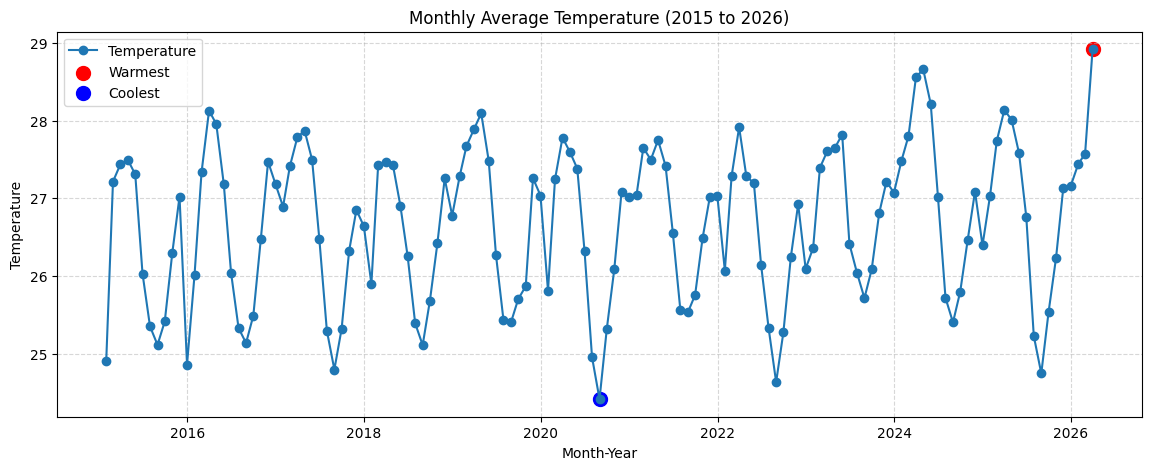

Warmest Month: 2026-03-31 00:00:00
Coolest Month: 2020-08-31 00:00:00


In [15]:
#Plotting monthly Average Temperature

# Convert DATE column to datetime
df["Date"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

df.set_index("Date", inplace=True)

# Calculate monthly average temperature
monthly_temp = df["T2M"].resample("M").mean()

# Plotting monthly average Temperature
plt.figure(figsize=(14,5))

plt.plot(monthly_temp.index, monthly_temp.values, marker='o', label="Temperature")

# Find warmest and coolest months
warmest_month = monthly_temp.idxmax()
coolest_month = monthly_temp.idxmin()

warmest_value = monthly_temp.max()
coolest_value = monthly_temp.min()

# Highlight points
plt.scatter(warmest_month, warmest_value, color="red", s=100, label="Warmest")
plt.scatter(coolest_month, coolest_value, color="blue", s=100, label="Coolest") 

plt.title("Monthly Average Temperature (2015 to 2026)")
plt.xlabel("Month-Year")
plt.ylabel("Temperature")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()

print("Warmest Month:", warmest_month)
print("Coolest Month:", coolest_month)


**Monthly Temperature Analysis**

Seasonality: it shows a clear repeating seasonal pattern, indicating consistent climate cycles over the years and spike in 2026

**Monthly total rainfall**

C:\Users\user\AppData\Local\Temp\ipykernel_10268\1343323091.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_rain = df["PRECTOTCORR"].resample("M").sum()


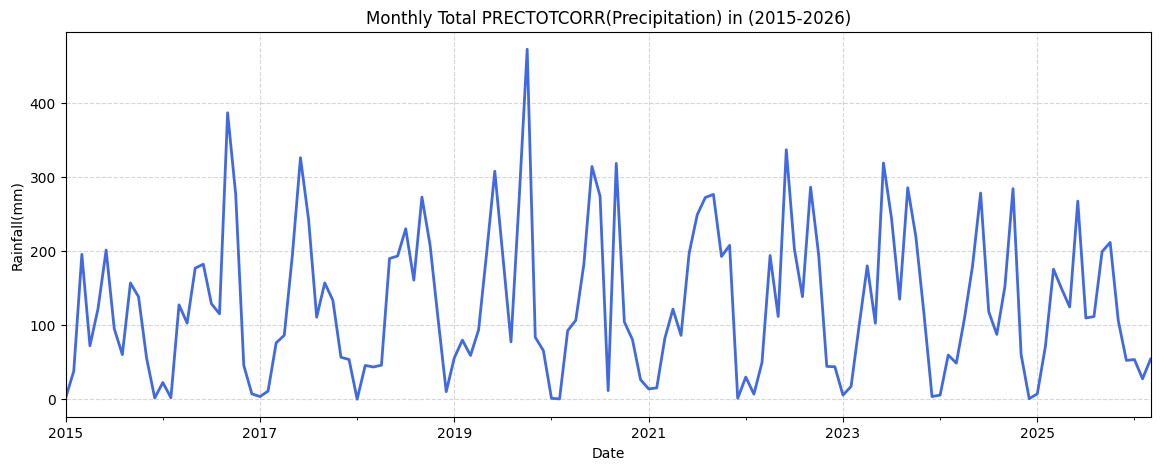

Rainy Months:
 Date
2019-10-31    471.90
2016-09-30    386.21
2022-06-30    336.36
Name: PRECTOTCORR, dtype: float64


In [16]:
#Plotting monthly Total Rainfall

# Convert DATE column to datetime
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df.set_index("Date", inplace=True)

monthly_rain = df["PRECTOTCORR"].resample("M").sum()

plt.figure(figsize=(14,5))

monthly_rain.plot(color='royalblue', linewidth=2)

plt.title("Monthly Total PRECTOTCORR(Precipitation) in (2015-2026)")
plt.xlabel("Date")
plt.ylabel("Rainfall(mm)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#Identifying peak rainy months
top_rain = monthly_rain.sort_values(ascending=False).head(3)
print("Rainy Months:\n", top_rain)

### 5. Correlation and RelationShip Analysis

 Heatmap of correlations across all numeric columns


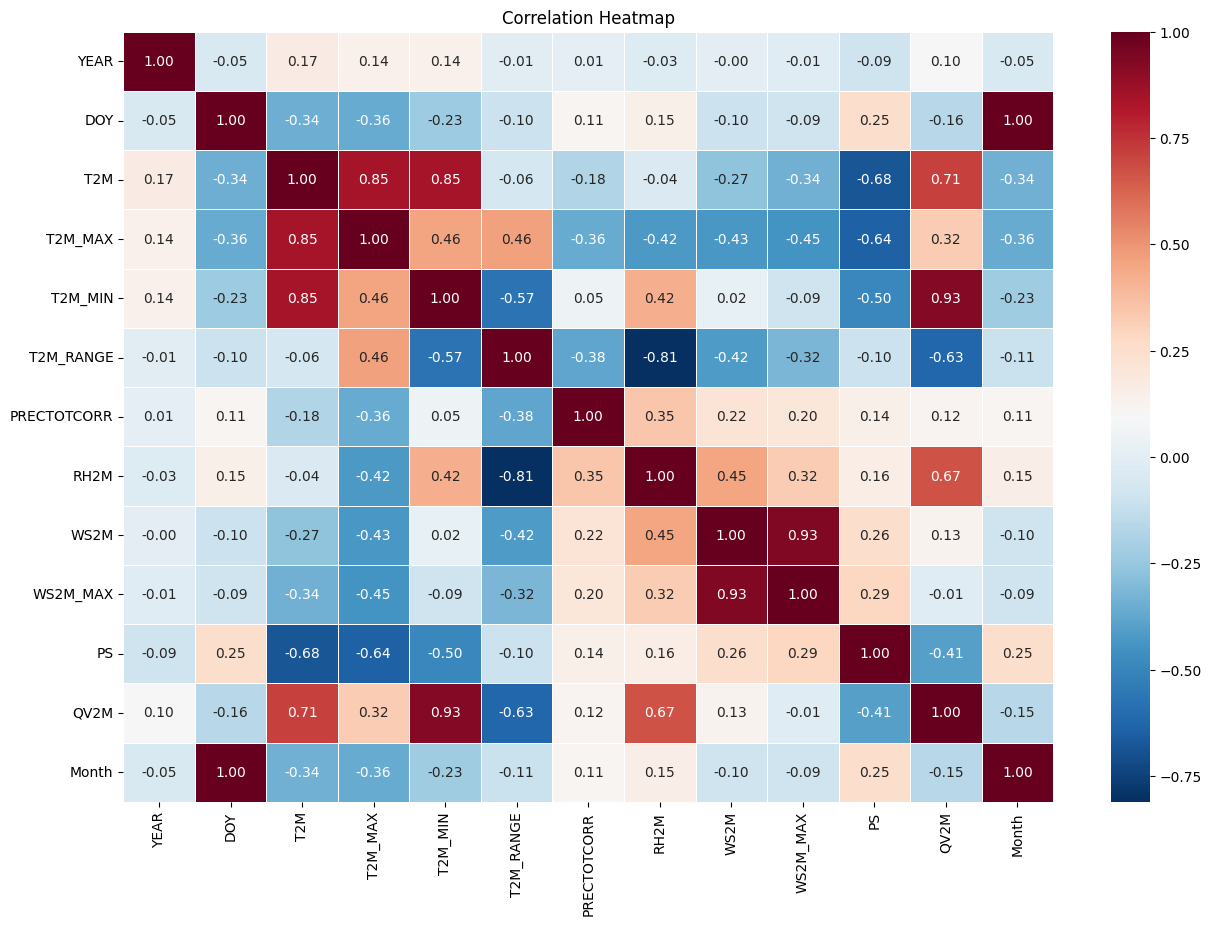

In [17]:
print(" Heatmap of correlations across all numeric columns")
#Select numeric columns
corr = df.select_dtypes(include="number").corr()

# Plotting a heatmap
plt.figure(figsize=(15,10))
sns.heatmap(corr, annot=True, fmt='.2f',  cmap='RdBu_r', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


**Correlation & Relationship Analysis**

- The Darker colors signify strong correlation, while light colors represents weaker correlations.

- Temperature and Humidity have positive correlation and move in same directions. As Temperature increases, humidity also increases. 

- Negative correlation variables move in opposite directions. An increase in one variable is associated with a decrease in the other.

**Scatter Plot 1: T2M vs RH2M**

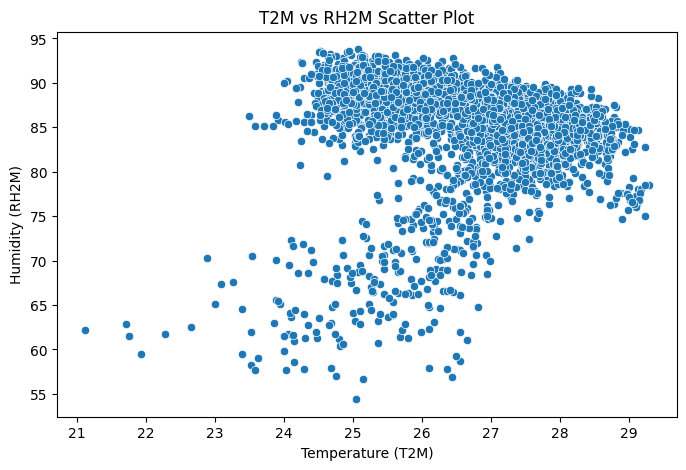

In [18]:
#Scatter plot between Temperature and Humidity
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["T2M"], y=df["RH2M"])

plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")

plt.title("T2M vs RH2M Scatter Plot")
plt.show()

**Scatter Plot 2: T2M_RANGE vs WS2M**

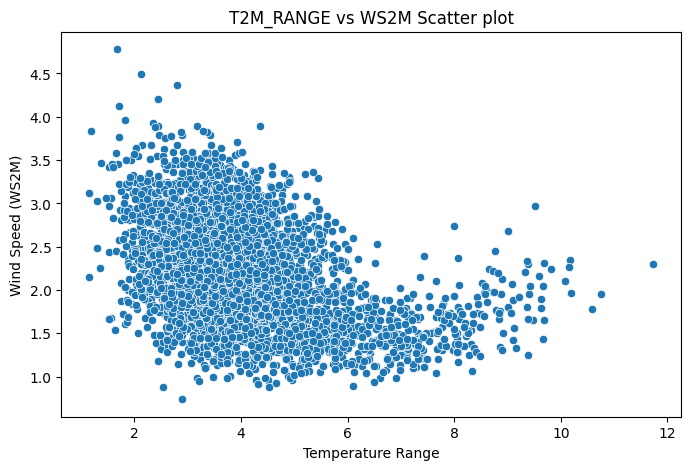

In [19]:
##Scatter plot between Temperature and Humidity

plt.figure(figsize=(8,5))
sns.scatterplot(x=df["T2M_RANGE"], y=df["WS2M"])

plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed (WS2M)")

plt.title("T2M_RANGE vs WS2M Scatter plot")
plt.show()

**The strongest correlations**

In [20]:
corr = df.select_dtypes(include="number").corr()

# Convert correlation matrix into pairs
corr_pairs = corr.unstack()

# Remove self-correlation (1.0)
corr_pairs = corr_pairs[corr_pairs != 1]

#remove duplicate pairs
corr_pairs = corr_pairs.drop_duplicates()

# Sort by strongest absolute correlation
strongest = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index)


# Top 3 strongest correlations
print(strongest.head(3))

DOY      Month       0.996557
WS2M     WS2M_MAX    0.930498
T2M_MIN  QV2M        0.925087
dtype: float64


**Strongest Correlations Analysis**

I. DOY vs Month — 0.9966 (Very Strong Positive Correlation)

- This extremely high correlation indicates that Day of Year (DOY) and Month are almost perfectly aligned.
- This is a redundant temporal relationship, not a physical climate interaction.

II. WS2M vs WS2M_MAX — 0.9304

- This shows that average wind speed and maximum wind speed increase together strongly.
- This reflects consistent wind behavior patterns, where calm and windy days scale together.

III. T2M vs T2M_MAX — 0.9250

- Warmer days tend to have higher peak temperatures

### 6. Distribution Analysis

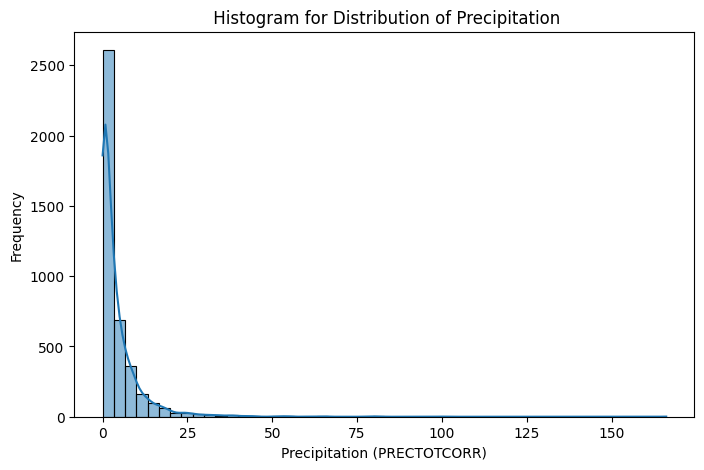

In [21]:
plt.figure(figsize=(8,5))

# Use log scale if data is highly skewed
sns.histplot(df["PRECTOTCORR"], bins=50, kde=True)

plt.xlabel("Precipitation (PRECTOTCORR)")
plt.ylabel("Frequency")
plt.title(" Histogram for Distribution of Precipitation")

plt.show()

**Precipitation Distribution**

- The distribution is highly right-skewed (positively skewed), most values are concentrated near 0 precipitation and a few values extend up to around 150+, but they are rare. 

**Bubble Chart T2M vs RH2M, bubble size = PRECTOTCORR**

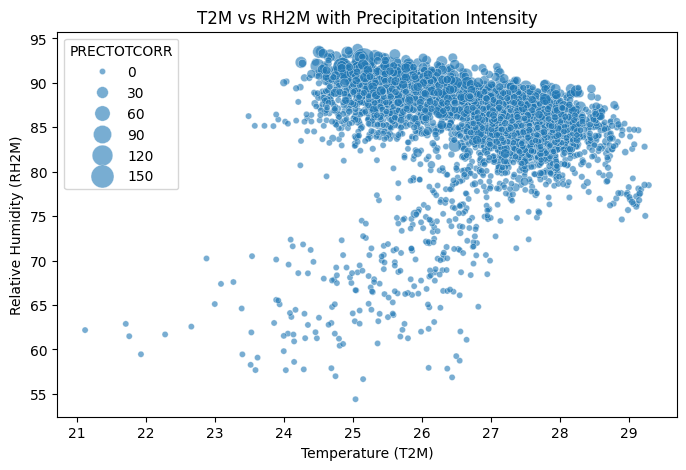

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="T2M",
    y="RH2M",
    size="PRECTOTCORR",
    sizes=(20, 300),
    alpha=0.6,
    legend=True
)

plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")
plt.title("T2M vs RH2M with Precipitation Intensity")
plt.show()

**Observation**

- There is a clear negative relationship between temperature and humidity and Moderate temperature range (~24°C to 28°C), Higher humidity zones (~80%–90%)
Precipitation is influenced by a combination of moderate temperature and high humidity, rather than extreme values of either variable.